In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

from LoadTSV import read_solution_file, interpolate_solution, sol_final

In [2]:
# Setup
# Solver and simulation parameters
M = 8
closure = "ExtGram"
Kn = 1.0
source = "relaxation_source"
T_end = 0.3
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11, 12, 13, 14]
polydeg = 1

# Initial condition parameters for the Riemann problem
rho_L = 7.0
v_L = 0.0
theta_L = 1.0
rho_R = 1.0
v_R = 0.0
theta_R = 1.0

# Some Comparison Plotting

/tmp/ipykernel_32403/3628364578.py:37: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


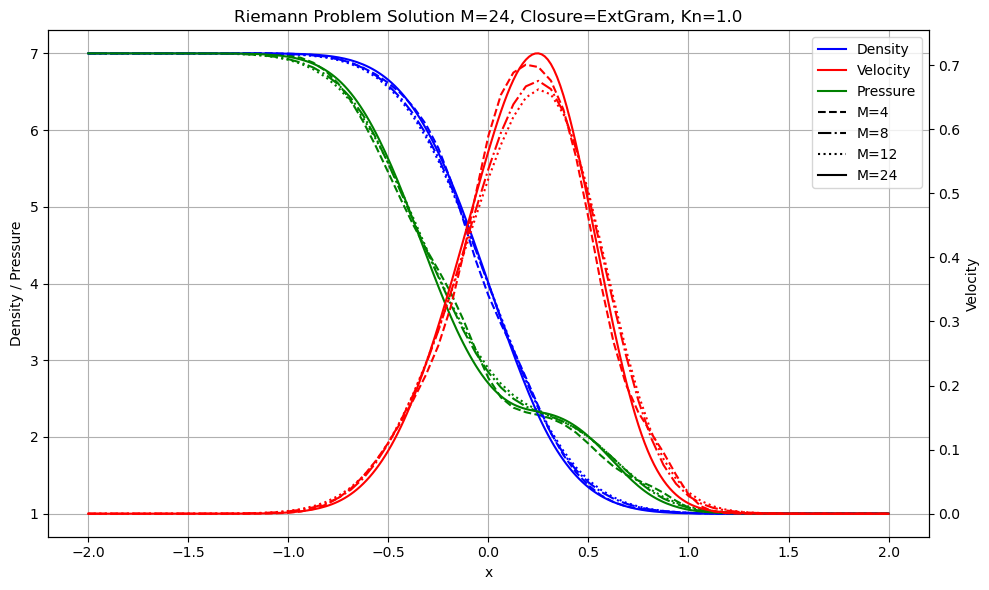

In [3]:
source_string = 'relaxation_source'
M_comparison = [4, 8, 12, 24]
base_tree_level_comparison = 6

fig, axs = plt.subplots(figsize=(10, 6))
twinx = axs.twinx()
linestyles = ['--', '-.', ':', '-']

for i, M in enumerate(M_comparison):
    filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level_comparison}_polydeg{polydeg}_cons.tsv"
    x, u, _ = sol_final(filename)

    rho = u[:, 0]
    v = u[:, 1] / rho
    p = u[:, 2] - rho * v**2
    axs.plot(x, rho, linestyle=linestyles[i], color='blue')
    twinx.plot(x, v, linestyle=linestyles[i], color='red')
    axs.plot(x, p, linestyle=linestyles[i], color='green')

axs.set_xlabel('x')
axs.set_ylabel('Density / Pressure')
twinx.set_ylabel('Velocity')
axs.set_title(f'Riemann Problem Solution M={M}, Closure={closure}, Kn={Kn}')

axs.plot([], [], color='blue', label='Density')
axs.plot([], [], color='red', label='Velocity')
axs.plot([], [], color='green', label='Pressure')
axs.plot([], [], color='black', linestyle=linestyles[0], label='M=4')
axs.plot([], [], color='black', linestyle=linestyles[1], label='M=8')
axs.plot([], [], color='black', linestyle=linestyles[2], label='M=12')
axs.plot([], [], color='black', linestyle=linestyles[3], label='M=24')
axs.legend(loc='upper right')
axs.grid()

fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/gram_solution_M_comparison.pdf')
fig.show()

# Convergence

In [4]:
order_x = [10**(1), 10**(3)]
offset_first_order = 0.5
first_order_y = [(1 + offset_first_order) * 10**(-1), (1 + offset_first_order) * 10**(-4/2)] 
offset_second_order = -0.5
second_order_y = [(1 + offset_second_order) * 10**(-1), (1 + offset_second_order) * 10**(-3)] 

/tmp/ipykernel_32403/2741364520.py:81: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_32403/2741364520.py:81: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()
/tmp/ipykernel_32403/2741364520.py:81: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


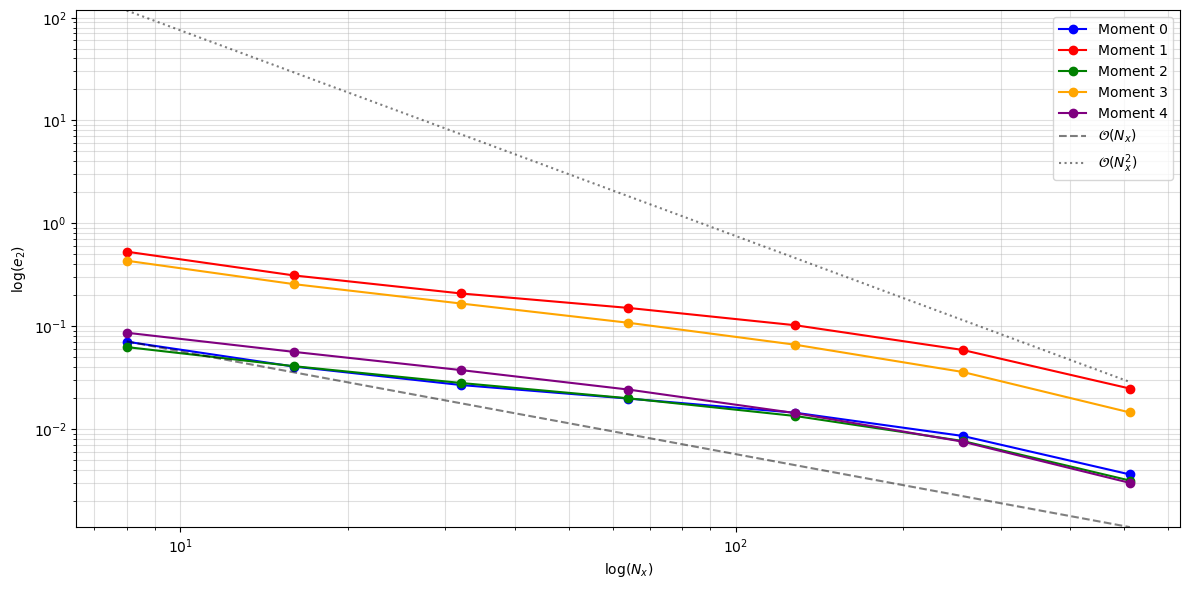

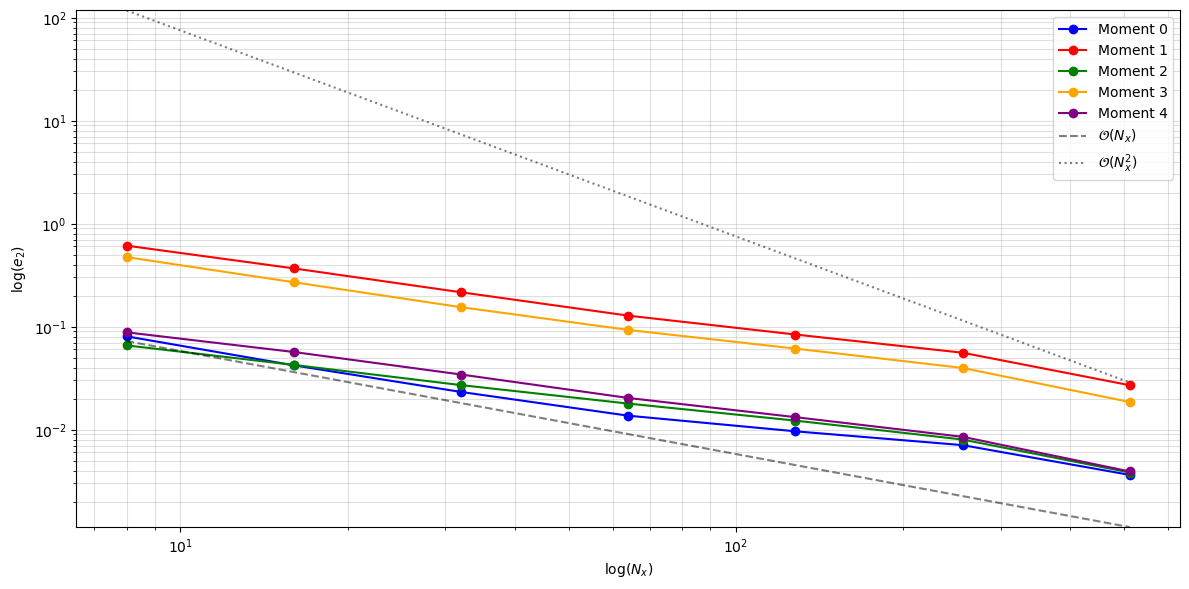

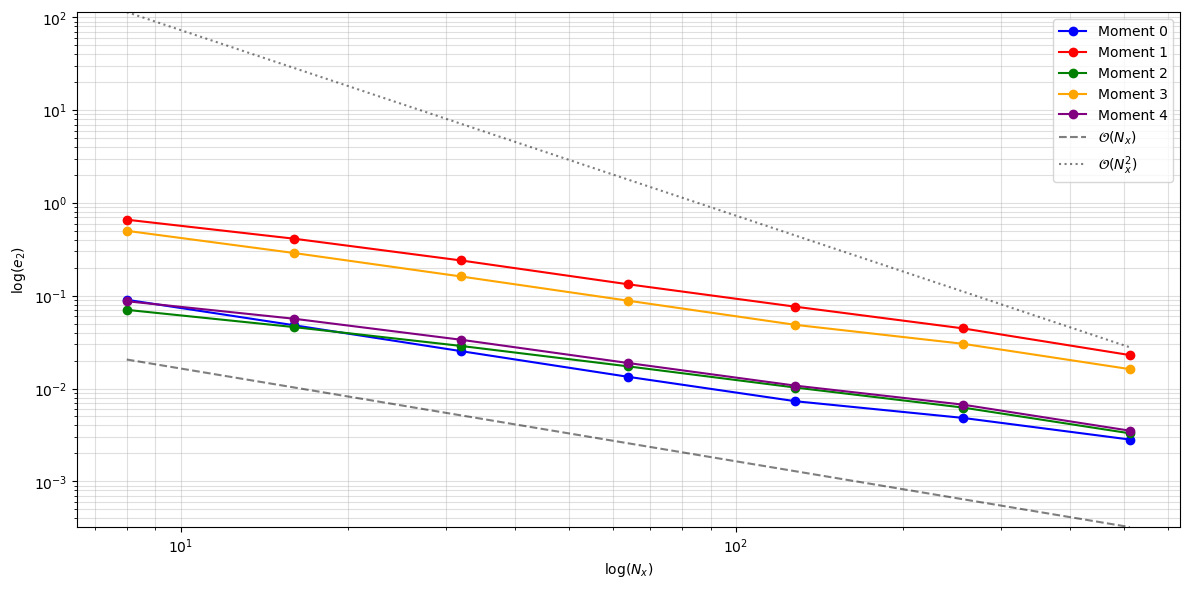

In [5]:
Moments = [4, 8, 12]
base_tree_level_vec = [3, 4, 5, 6, 7, 8, 9, 10]#![2, 4, 6, 7, 8, 9, 10] #!, 11, 12, 13]
source_string = 'relaxation_source'
for M in Moments:
    moment_solutions = []
    x_solutions = []
    # figrho, axsrho = plt.subplots(figsize=(10, 6))
    # figv, axsv = plt.subplots(figsize=(10, 6))
    # figp, axsp = plt.subplots(figsize=(10, 6))
    for base_tree_level in base_tree_level_vec:
        filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
        
        data = read_solution_file(filename)

        # Build time → timestep mapping
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))

        time_query = 21 # last time step
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, u, t = sol["x"], sol["u"], sol["t"]

        x_solutions.append(x)
        moment_solutions.append(u)  # Store all moments

        rho = u[:, 0]
        v = u[:, 1] / rho
        p = u[:, 2] - rho * v**2
    #     axsrho.plot(x, rho, label=f'Level={base_tree_level}')
    #     axsv.plot(x, v, label=f'Level={base_tree_level}')
    #     axsp.plot(x, p, label=f'Level={base_tree_level}')
    # [ax.legend() for ax in [axsrho, axsv, axsp]]
    # [ax.grid(True) for ax in [axsrho, axsv, axsp]]
    # [fig.tight_layout() for fig in [figrho, figv, figp]]
    # [fig.show() for fig in [figrho, figv, figp]]
    errors = {}
    Nx = []
    for mom in range(5):
        errors[mom] = []
        ref_solution = interp1d(x_solutions[-1], moment_solutions[-1][:, mom])  # Using the same data as reference for simplicity
        for j, tree_level in enumerate(base_tree_level_vec[:-1]):
            data_trixi = moment_solutions[j][:, mom]
            # error = np.linalg.norm(ref_solution(x_solutions[j]) - data_trixi, 2) / np.linalg.norm(ref_solution(x_solutions[j]), 2)
            trixi_solution = interp1d(x_solutions[j], data_trixi, kind='linear', fill_value="extrapolate") # ! cubic
            # error = np.linalg.norm(moment_solutions[-1][:, mom] - trixi_solution(x_solutions[-1]), 2) / np.linalg.norm(moment_solutions[-1][:, mom], 2)
            diff = ref_solution(x_solutions[-1]) - trixi_solution(x_solutions[-1])
            # error = np.sqrt(np.mean(diff**2))
            error = np.mean(np.abs(diff)) / np.mean(np.abs(ref_solution(x_solutions[-1])))
            errors[mom].append(error)
            if mom == 0:
                Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

    colors = ['blue', 'red', 'green', 'orange', 'purple']

    fig, axs = plt.subplots(figsize=(12,6))
    for mom in range(5):
        axs.loglog(Nx, errors[mom], marker='o', color=colors[mom], label=f'Moment {mom}')

    # --- Add Reference Slopes ---
    # Calculate dummy lines based on the last data point of Moment 0
    Nx = np.array(Nx)
    ref_y = np.array(errors[0][-1])
    ref_x_last = Nx[-1]
    
    # Slope 1: O(N^-1)
    slope1 = (ref_y - 2.5e-3) * (Nx / ref_x_last)**(-1)
    axs.loglog(Nx, slope1, 'k--', alpha=0.5, label='$\mathcal{O}(N_x)$')
    
    # Slope 2: O(N^-2)
    slope2 = (ref_y + 2.5e-2) * (Nx / ref_x_last)**(-2)
    axs.loglog(Nx, slope2, 'k:', alpha=0.5, label='$\mathcal{O}(N_x^2)$')
    axs.set_xticks([10**1, 10**2]) #!, 10**3])
    axs.set_xlabel('$\log(N_x)$')
    axs.set_ylabel('$\log(e_2)$')
    # axs.grid(True)
    axs.grid(True, which="both", ls="-", alpha=0.4)
    axs.set_ylim(slope1[-1], slope2[0])
    axs.legend()
    fig.tight_layout()
    fig.savefig(f'../out/Figures/Riemann1D/GridConvergence_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}.pdf')
    fig.show()

Processing Moment M=4...


/tmp/ipykernel_32403/4273571744.py:150: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig_conv.show()


Processing Moment M=8...
Processing Moment M=12...
Routine complete.


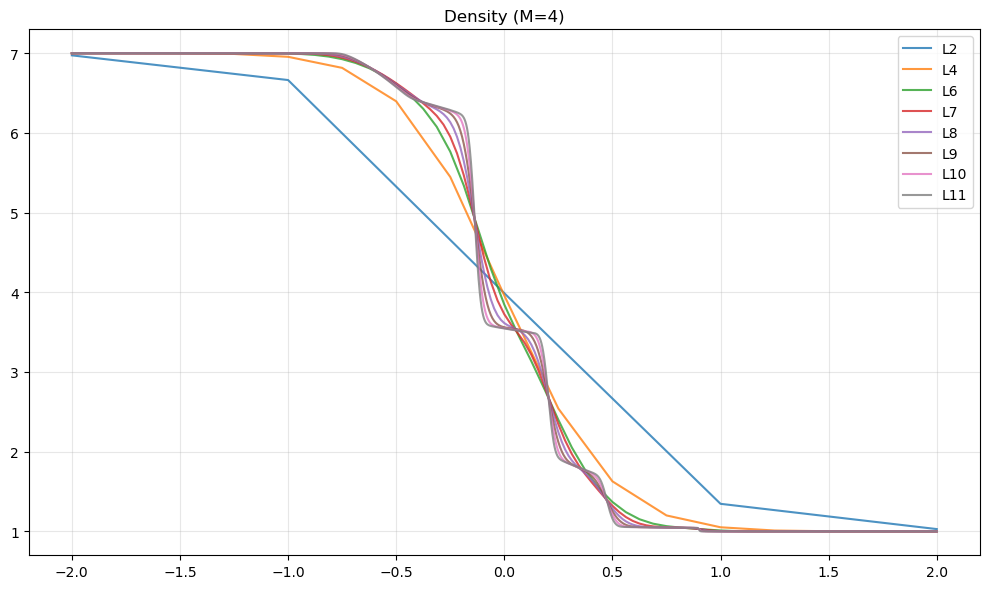

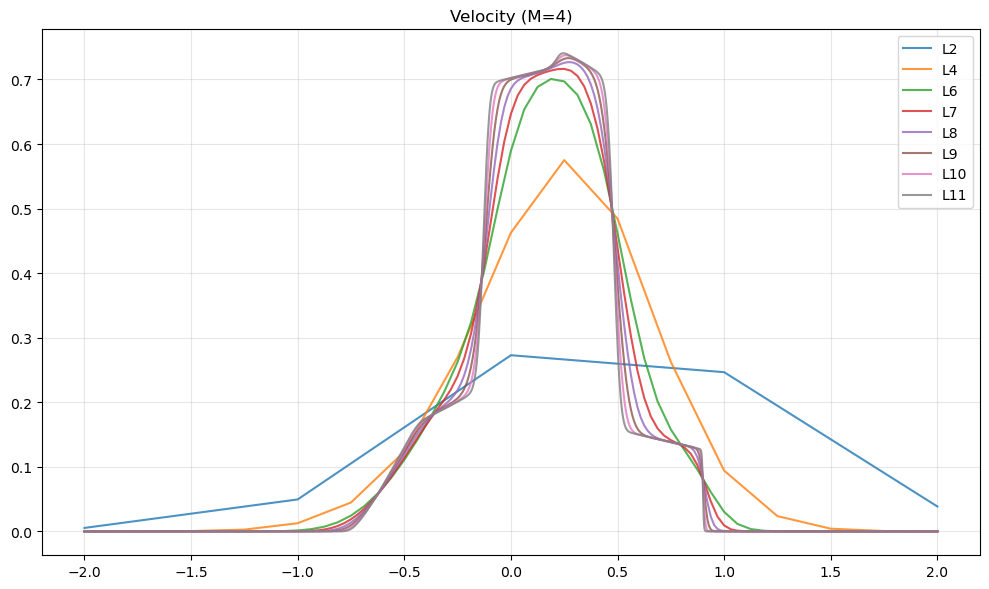

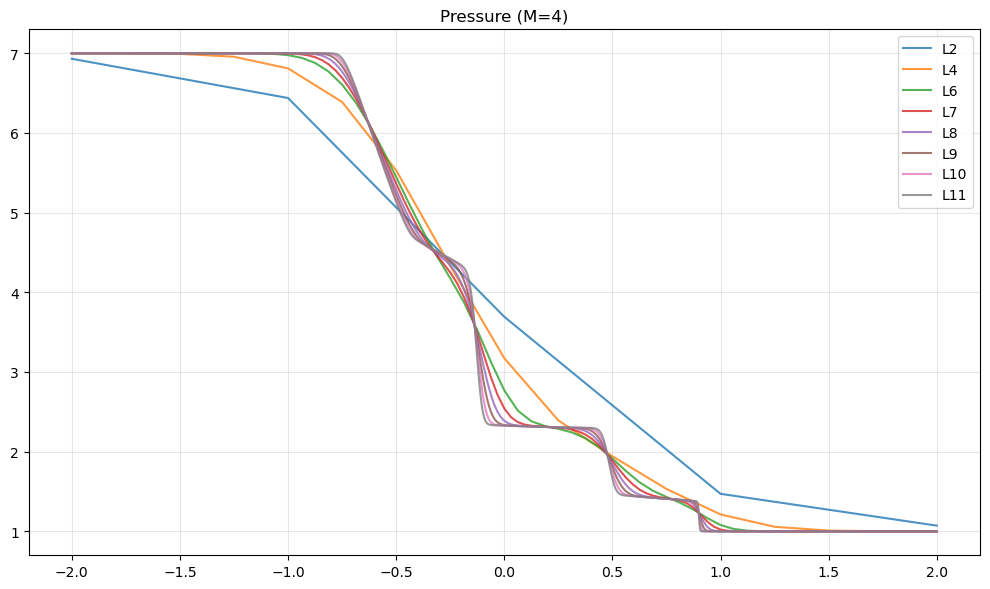

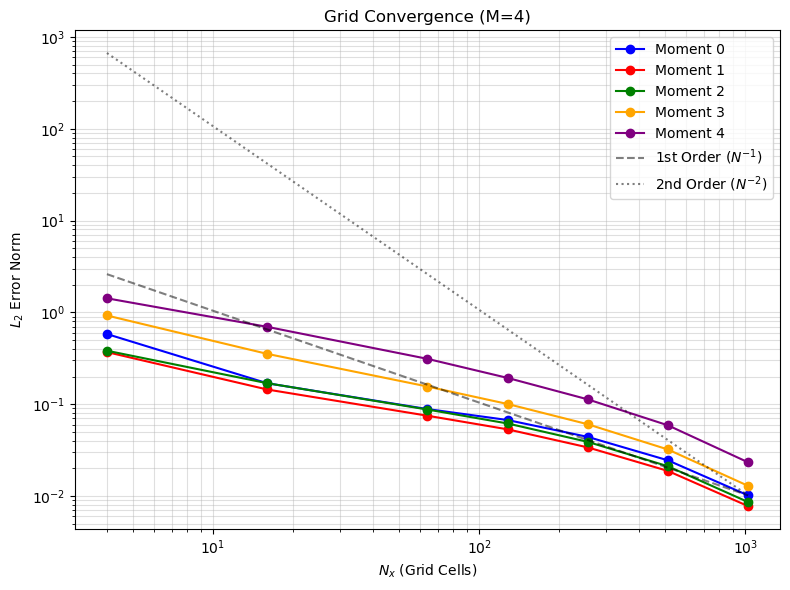

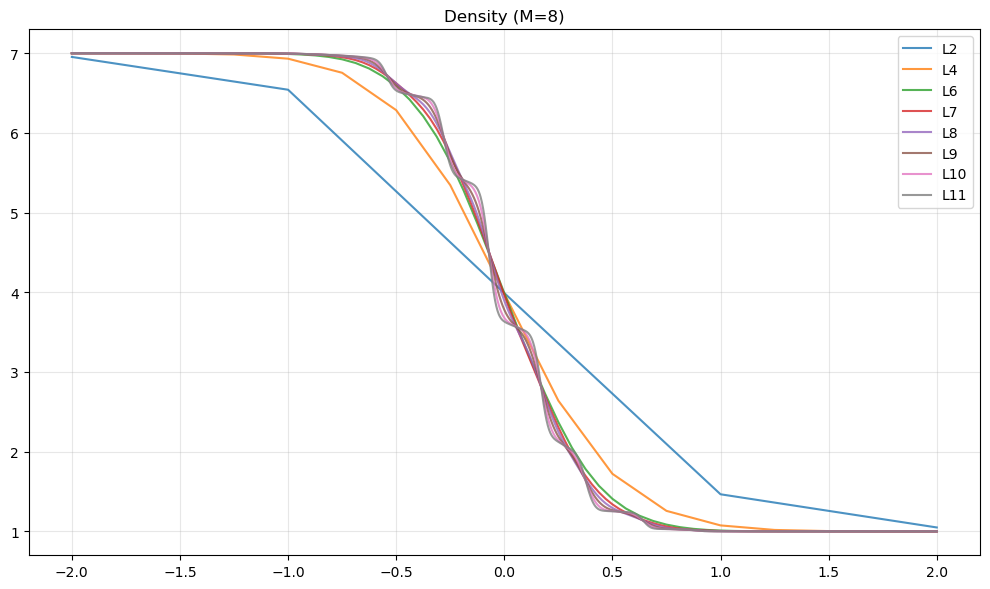

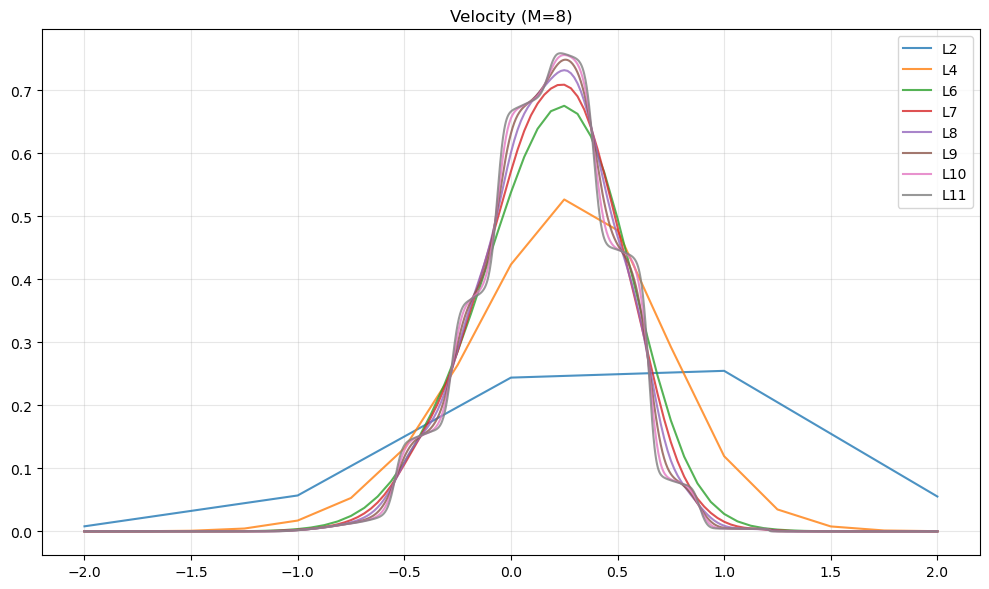

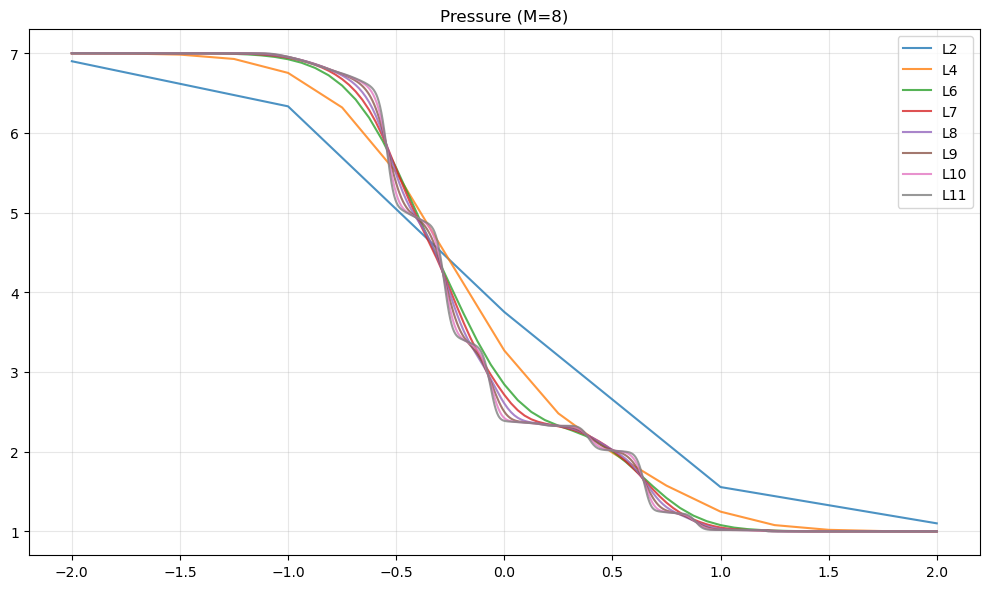

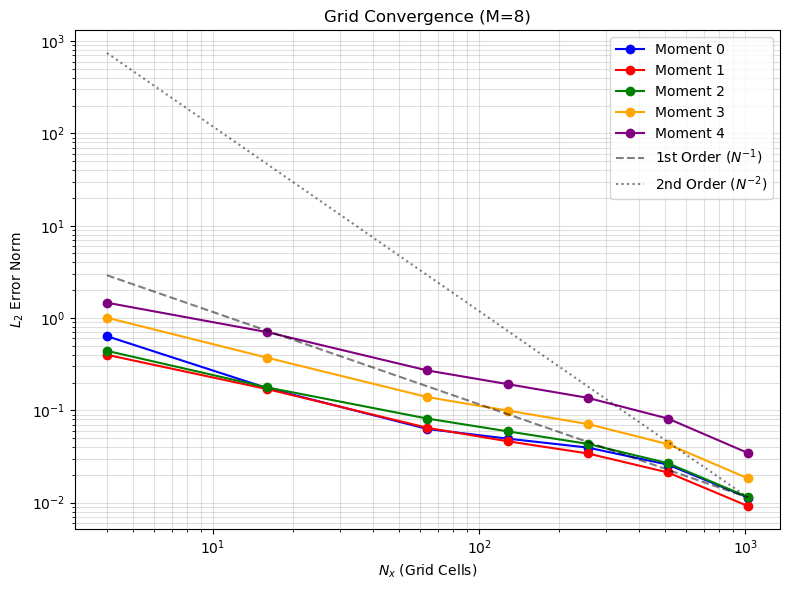

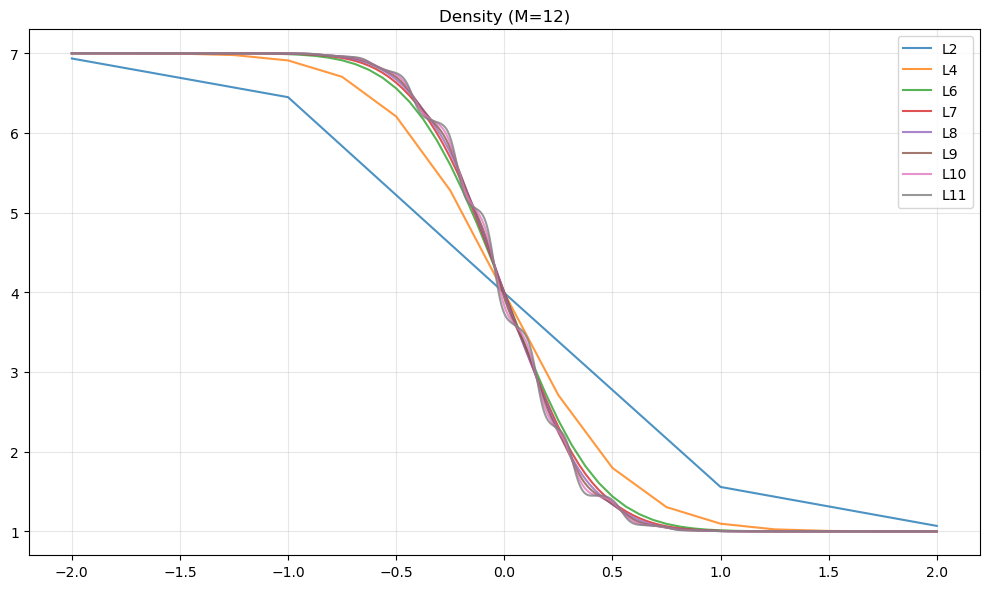

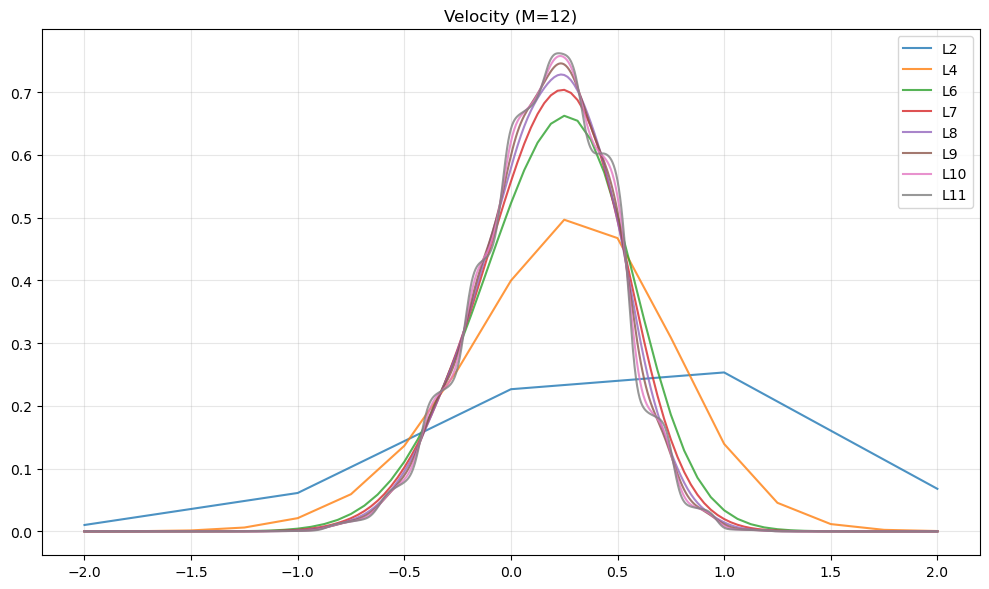

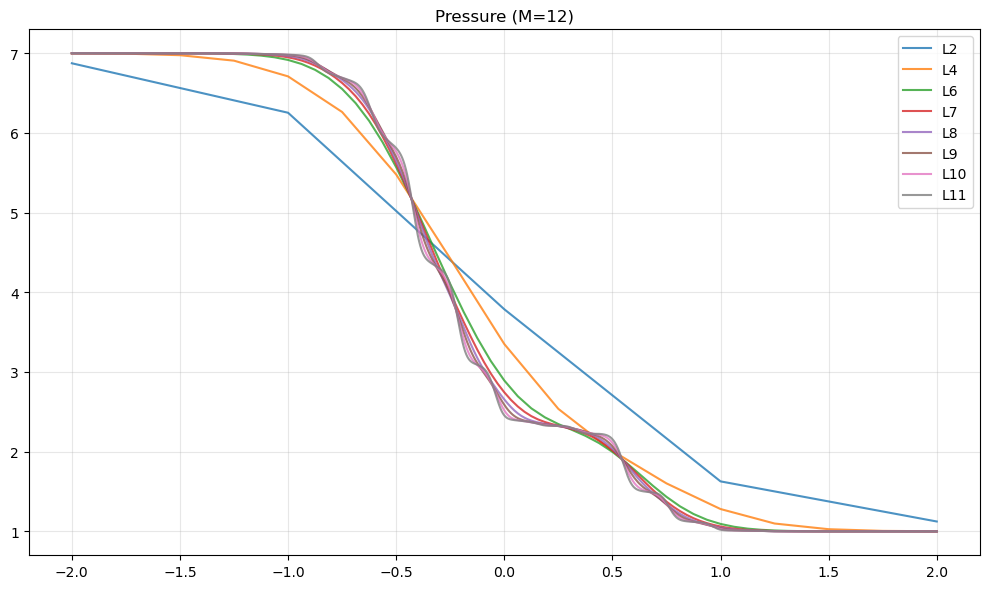

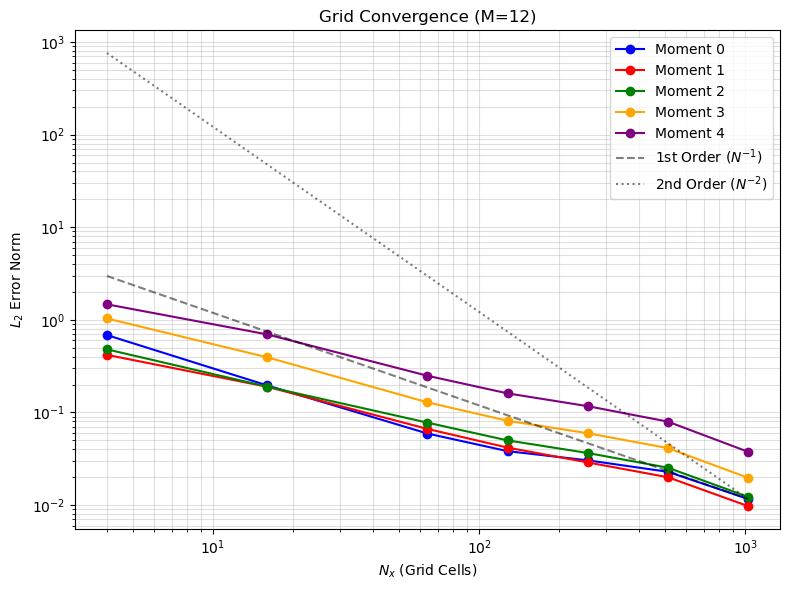

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- Settings ---
Moments = [4, 8, 12]
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11] #![2, 4, 6, 7, 8, 9, 10] # Fine grid (Level 10) is reference
source_string = 'relaxation_source'

# Toggle interpolation method
# Use 'linear' for solutions with Shocks (Riemann problems) to avoid Gibbs oscillations
# Use 'cubic' for Smooth solutions to verify high-order convergence
interp_kind = 'linear' 

for M in Moments:
    print(f"Processing Moment M={M}...")
    
    # --- RESET Storage for this Moment ---
    moment_solutions = []
    x_solutions = []
    Nx_values = [] # Store grid sizes
    
    # Prepare Profile Plots
    figrho, axsrho = plt.subplots(figsize=(10, 6))
    figv, axsv = plt.subplots(figsize=(10, 6))
    figp, axsp = plt.subplots(figsize=(10, 6))
    
    # --- 1. Load Data Loop ---
    for base_tree_level in base_tree_level_vec:
        filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
        
        # (Assuming read_solution_file and interpolate_solution are defined elsewhere)
        data = read_solution_file(filename)
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))
        
        time_query = 21 # last time step
        sol = interpolate_solution(data, time_query, times, timesteps)
        
        x = sol["x"]
        u = sol["u"] # Shape: (N_points, N_variables)
        
        x_solutions.append(x)
        moment_solutions.append(u)
        
        # Calculate Number of Elements/DOFs for this level
        # Assuming tree_level maps to 2^level cells
        Nx_values.append(2**base_tree_level)

        # Plot Profiles
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = u[:, 2] - rho * v**2
        
        # Use simpler labels for legend
        lbl = f'L{base_tree_level}'
        axsrho.plot(x, rho, label=lbl, alpha=0.8)
        axsv.plot(x, v, label=lbl, alpha=0.8)
        axsp.plot(x, p, label=lbl, alpha=0.8)

    # Finalize Profile Plots
    for ax, title in zip([axsrho, axsv, axsp], ['Density', 'Velocity', 'Pressure']):
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_title(f"{title} (M={M})")
    
    [fig.tight_layout() for fig in [figrho, figv, figp]]
    # [fig.show() for fig in [figrho, figv, figp]] # Comment out to avoid flooding screen
    
    # --- 2. Calculate Convergence Errors ---
    # Reference is the finest grid (last element in lists)
    ref_x = x_solutions[-1]
    ref_u = moment_solutions[-1] 
    
    # Store errors for plotting: keys are moment indices (0..4)
    errors_by_moment = {m: [] for m in range(5)}
    
    # Loop over Coarse grids (all except the last one)
    for j in range(len(base_tree_level_vec) - 1):
        coarse_x = x_solutions[j]
        coarse_u = moment_solutions[j]
        
        for mom in range(5):
            # A. Get Coarse Data for this moment
            coarse_data_mom = coarse_u[:, mom]
            ref_data_mom = ref_u[:, mom]
            
            # B. Interpolate Coarse -> Fine Grid
            # This projects the coarse approximation onto the fine grid coordinates
            f_interp = interp1d(coarse_x, coarse_data_mom, kind=interp_kind, fill_value="extrapolate")
            u_coarse_on_fine = f_interp(ref_x)
            
            # # C. Calc L2 Error against Reference Data
            # diff = u_coarse_on_fine - ref_data_mom
            # l2_error = np.sqrt(np.mean(diff**2))
            
            # errors_by_moment[mom].append(l2_error)

            # 1. Standard L1 Norm (The "Conservation" Error)
            diff = u_coarse_on_fine - ref_data_mom
            l1_error = np.mean(np.abs(diff))
            
            # 2. Wasserstein Distance (The "Shift" Error)
            # scipy.stats.wasserstein_distance(u_values, v_values, u_weights, v_weights)
            # We treat the solution profiles as "probability distributions" (mass histograms)
            # Note: This works best for positive quantities like Density (rho). 
            # For Velocity/Pressure, it's less physically meaningful but still mathematically valid.
            
            # We use the grid coordinates (ref_x) as the "values" and the solution (rho) as "weights"
            # if mom == 0: # Only do this for Density (rho) as it is conserved and positive
            #     # Normalize to sum to 1 (like a probability distribution) for the function to work
            #     w_ref = ref_data_mom / np.sum(ref_data_mom)
            #     w_coarse = u_coarse_on_fine / np.sum(u_coarse_on_fine)
                
            #     wd_error = wasserstein_distance(ref_x, ref_x, w_coarse, w_ref)
            # else:
            #     wd_error = np.nan

            errors_by_moment[mom].append(l1_error) # Or switch to wd_error to plot that

    # --- 3. Convergence Plot ---
    fig_conv, ax_conv = plt.subplots(figsize=(8, 6))
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    
    # X-axis: Nx values of the COARSE grids only
    nx_plot = np.array(Nx_values[:-1]) 
    
    for mom in range(5):
        ax_conv.loglog(nx_plot, errors_by_moment[mom], 'o-', color=colors[mom], label=f'Moment {mom}')

    # --- Add Reference Slopes ---
    # Calculate dummy lines based on the last data point of Moment 0
    ref_y = errors_by_moment[0][-1]
    ref_x_last = nx_plot[-1]
    
    # Slope 1: O(N^-1)
    slope1 = ref_y * (nx_plot / ref_x_last)**(-1)
    ax_conv.loglog(nx_plot, slope1, 'k--', alpha=0.5, label='1st Order ($N^{-1}$)')
    
    # Slope 2: O(N^-2)
    slope2 = ref_y * (nx_plot / ref_x_last)**(-2)
    ax_conv.loglog(nx_plot, slope2, 'k:', alpha=0.5, label='2nd Order ($N^{-2}$)')

    ax_conv.set_xlabel('$N_x$ (Grid Cells)')
    ax_conv.set_ylabel('$L_2$ Error Norm')
    ax_conv.set_title(f'Grid Convergence (M={M})')
    ax_conv.grid(True, which="both", ls="-", alpha=0.4)
    ax_conv.legend()
    fig_conv.tight_layout()
    fig_conv.show()

print("Routine complete.")

/tmp/ipykernel_32403/3024523412.py:51: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


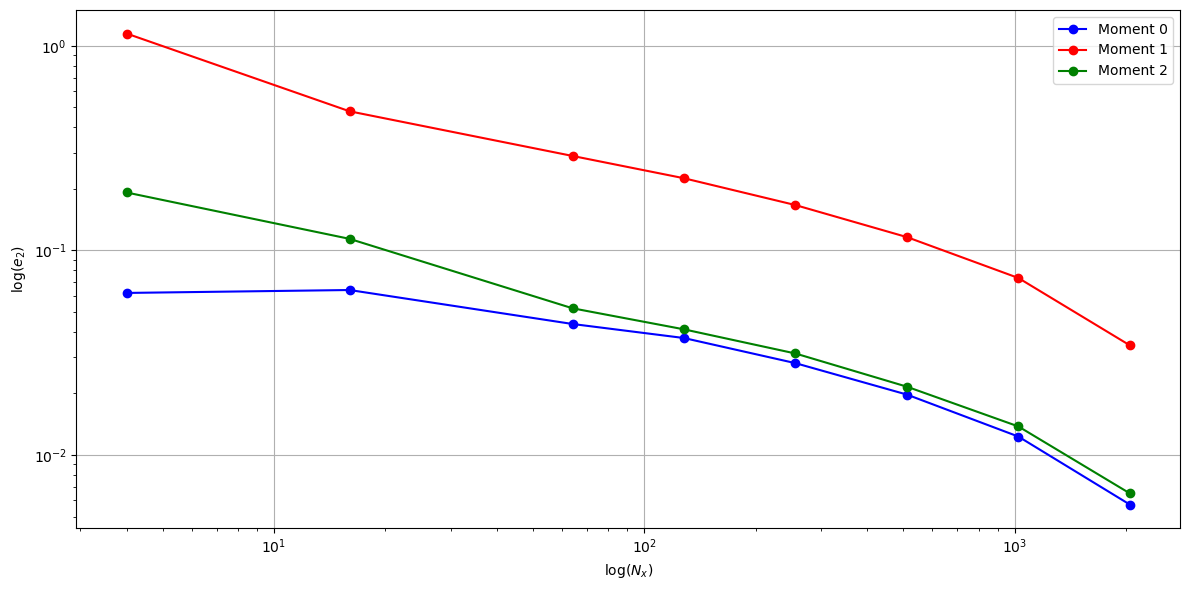

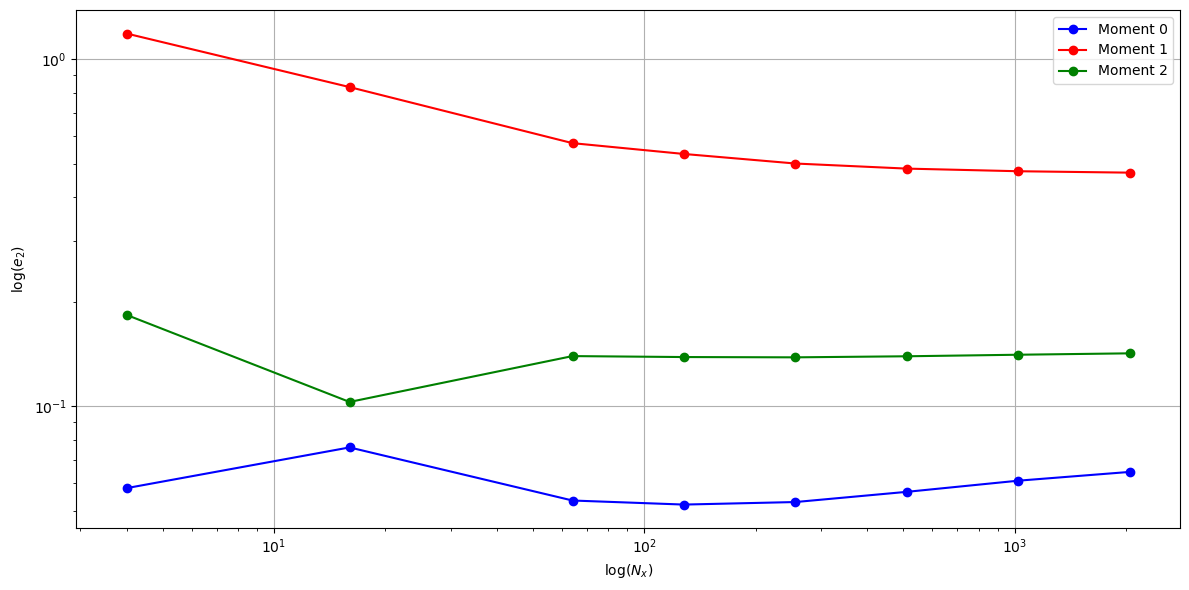

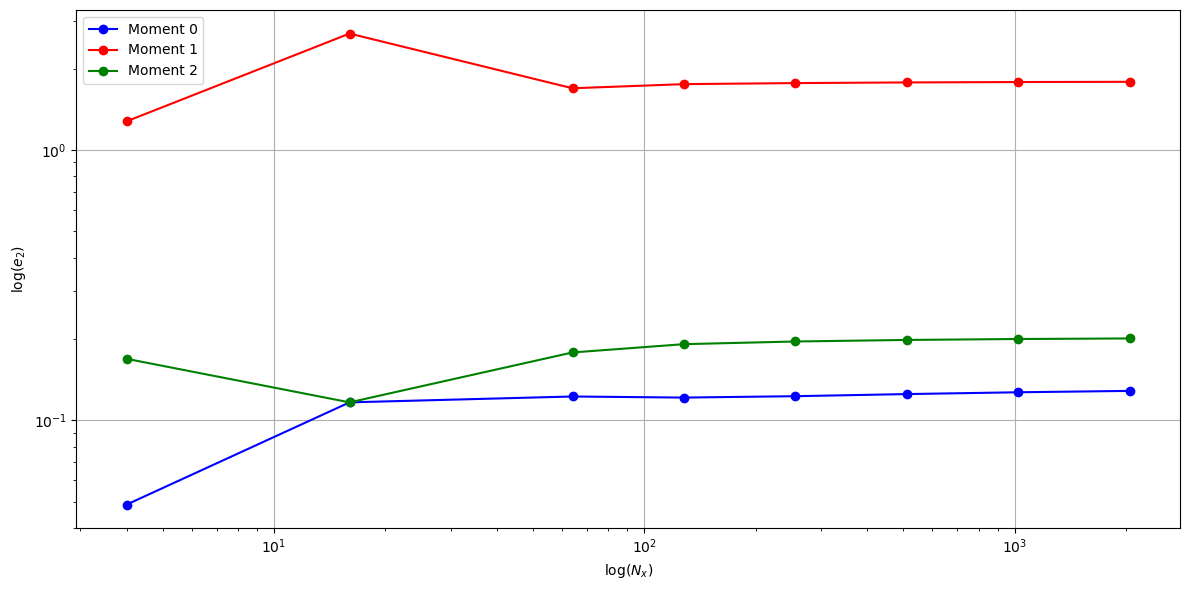

In [7]:
from LoadTSV import read_solution_file, interpolate_solution
Moments = [4, 8, 12]
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11, 12]
source_string = 'relaxation_source'
moment_solutions = []
x_solutions = []
for M in Moments:
    for base_tree_level in base_tree_level_vec:
        filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_prim.tsv"
        
        data = read_solution_file(filename)

        # Build time → timestep mapping
        times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
        timesteps = np.array(sorted(data.keys()))

        time_query = 21 # last time step
        sol = interpolate_solution(data, time_query, times, timesteps)
        x, u, t = sol["x"], sol["u"], sol["t"]

        x_solutions.append(x)
        # moment_solutions.append(u)  # Store all moments
        rho = u[:, 0]
        v = u[:, 1] / rho
        p = u[:, 2] - rho * v**2
        moment_solutions.append([rho, v, p])
    errors = {}
    Nx = []
    for mom in range(3):
        errors[mom] = []
        ref_solution = interp1d(x_solutions[-1], moment_solutions[-1][mom])  # Using the same data as reference for simplicity
        for tree_level in base_tree_level_vec[:-1]:
            data_trixi = moment_solutions[base_tree_level_vec.index(tree_level)][mom]
            error = np.linalg.norm(ref_solution(x_solutions[base_tree_level_vec.index(tree_level)]) - data_trixi, 2) / np.linalg.norm(ref_solution(x_solutions[base_tree_level_vec.index(tree_level)]), 2)
            errors[mom].append(error)
            if mom == 0:
                Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

    colors = ['blue', 'red', 'green', 'orange', 'purple']

    fig, axs = plt.subplots(figsize=(12,6))
    for mom in range(3):
        axs.loglog(Nx, errors[mom], marker='o', color=colors[mom], label=f'Moment {mom}')
    axs.set_xticks([10**1, 10**2, 10**3])
    axs.set_xlabel('$\log(N_x)$')
    axs.set_ylabel('$\log(e_2)$')
    axs.grid(True)
    axs.legend()
    fig.tight_layout()
    # fig.savefig(f'../out/Figures/Riemann1D/GridConvergence_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}.pdf')
    fig.show()

In [8]:
x_solutions[-1].size, moment_solutions[-1][0]

(4097, array([7., 7., 7., ..., 1., 1., 1.]))

/tmp/ipykernel_32403/1144368288.py:36: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


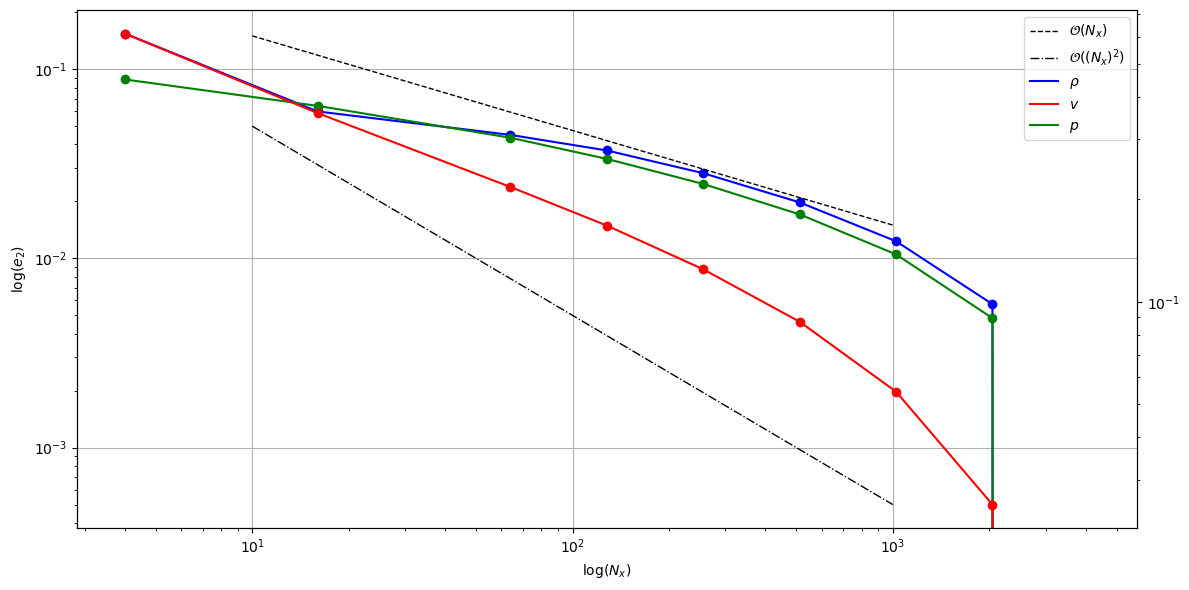

In [9]:
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11, 12]#!, 13, 14]
M = 4
file_gramian = [f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv" for base_tree_level in base_tree_level_vec]
data_gramian = [pd.read_csv(f) for f in file_gramian]

errors = {}
Nx = []
for key in ['rho', 'v', 'p']:
    errors[key] = []
    ref_solution = interp1d(data_gramian[-1]['x'], data_gramian[-1][key])  # Using the same data as reference for simplicity
    for tree_level in base_tree_level_vec:
        data_trixi = data_gramian[base_tree_level_vec.index(tree_level)]
        error = np.linalg.norm(ref_solution(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(ref_solution(data_trixi['x']), 2)
        errors[key].append(error)
        if key == 'rho':
            Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

fig, axs = plt.subplots(figsize=(12,6))
axs.plot(Nx, errors['rho'], marker='o', color='blue')
twinx = axs.twinx()
twinx.loglog(Nx, errors['v'], marker='o', color='red')
axs.loglog(Nx, errors['p'], marker='o', color='green')
axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
axs.plot([], [], 'b-', label='$\\rho$')
axs.plot([], [], 'r-', label='$v$')
axs.plot([], [], 'g-', label='$p$')
axs.set_xticks([10**1, 10**2, 10**3])
axs.set_xlabel('$\log(N_x)$')
axs.set_ylabel('$\log(e_2)$')
axs.grid(True)
axs.legend()

fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/GridConvergence_M4.pdf')
fig.show()

In [10]:
from LoadTSV import read_solution_file, interpolate_solution
M = 8
source_string = 'relaxation_source'
moment_solutions = []
x_solutions = []
for base_tree_level in base_tree_level_vec:
    filename = f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source_string}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_cons.tsv"
    
    data = read_solution_file(filename)

    # Build time → timestep mapping
    times = np.array([data[ts]["t"] for ts in sorted(data.keys())])
    timesteps = np.array(sorted(data.keys()))

    time_query = 21 # last time step
    sol = interpolate_solution(data, time_query, times, timesteps)
    x, u, t = sol["x"], sol["u"], sol["t"]

    x_solutions.append(x)
    moment_solutions.append(u)  # Store all moments

In [11]:
errors = {}
Nx = []
for mom in range(5):
    errors[mom] = []
    ref_solution = interp1d(x_solutions[-1], moment_solutions[-1][:, mom])  # Using the same data as reference for simplicity
    for tree_level in base_tree_level_vec[:-1]:
        data_trixi = moment_solutions[base_tree_level_vec.index(tree_level)][:, mom]
        error = np.linalg.norm(ref_solution(x_solutions[base_tree_level_vec.index(tree_level)]) - data_trixi, 2) / np.linalg.norm(ref_solution(x_solutions[base_tree_level_vec.index(tree_level)]), 2)
        errors[mom].append(error)
        if mom == 0:
            Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

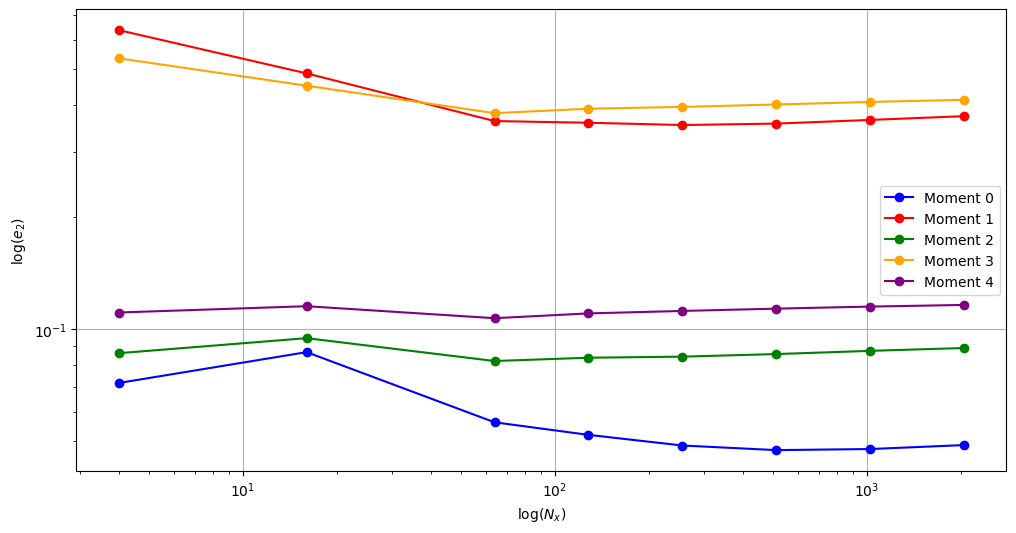

In [12]:
colors = ['blue', 'red', 'green', 'orange', 'purple']

fig, axs = plt.subplots(figsize=(12,6))
for mom in range(5):
    axs.loglog(Nx, errors[mom], marker='o', color=colors[mom], label=f'Moment {mom}')
axs.set_xticks([10**1, 10**2, 10**3])
axs.set_xlabel('$\log(N_x)$')
axs.set_ylabel('$\log(e_2)$')
axs.grid(True)
axs.legend()

In [13]:
order_x = [10**(1), 10**(3)]
offset_first_order = 0.5
first_order_y = [(1 + offset_first_order) * 10**(-1), (1 + offset_first_order) * 10**(-4/2)] 
offset_second_order = -0.5
second_order_y = [(1 + offset_second_order) * 10**(-1), (1 + offset_second_order) * 10**(-3)] 

/tmp/ipykernel_32403/2897831811.py:25: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig2.show()
/tmp/ipykernel_32403/2897831811.py:45: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


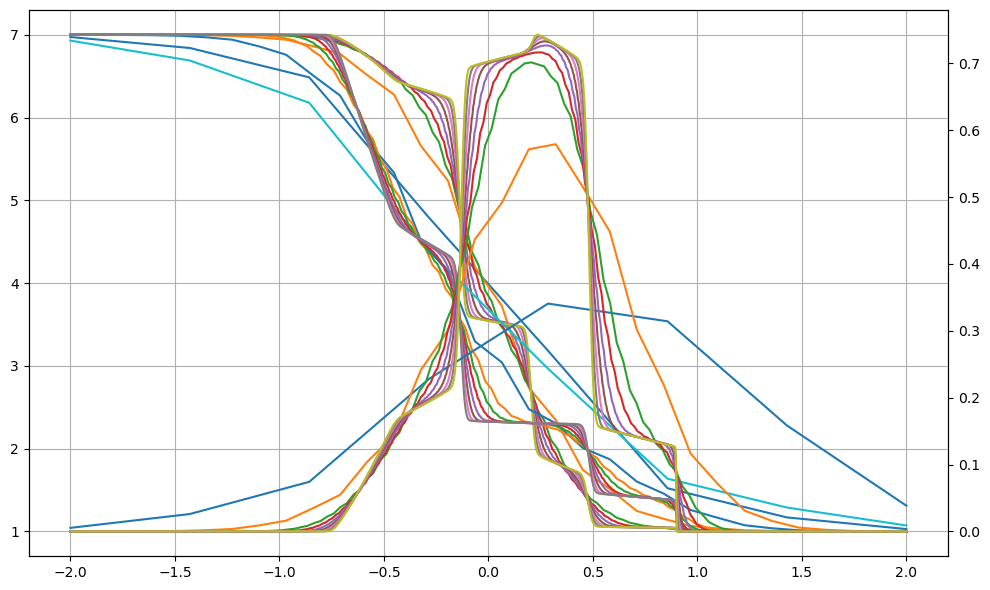

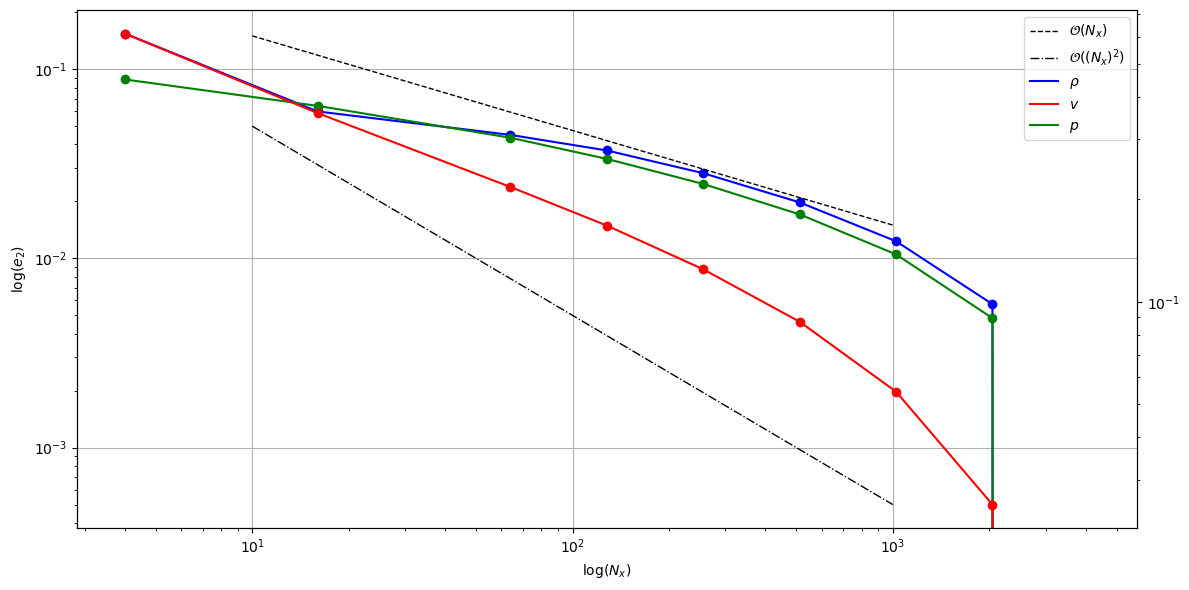

In [14]:
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11, 12]#!, 13, 14]
M = 4
file_gramian = [f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv" for base_tree_level in base_tree_level_vec]
data_gramian = [pd.read_csv(f) for f in file_gramian]

errors = {}
Nx = []
fig2, axs2 = plt.subplots(figsize=(10, 6))
twinx2 = axs2.twinx()
for key in ['rho', 'v', 'p']:
    errors[key] = []
    ref_solution = interp1d(data_gramian[-1]['x'], data_gramian[-1][key])  # Using the same data as reference for simplicity
    for tree_level in base_tree_level_vec:
        data_trixi = data_gramian[base_tree_level_vec.index(tree_level)]
        error = np.linalg.norm(ref_solution(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(ref_solution(data_trixi['x']), 2)
        errors[key].append(error)
        if key == 'rho':
            Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets
        if key in ['rho', 'p']:
            axs2.plot(data_trixi['x'], data_trixi[key], label=key)
        else:   
            twinx2.plot(data_trixi['x'], data_trixi[key], label=key)
axs2.grid(True)
fig2.tight_layout()
fig2.show()

fig, axs = plt.subplots(figsize=(12,6))
axs.plot(Nx, errors['rho'], marker='o', color='blue')
twinx = axs.twinx()
twinx.loglog(Nx, errors['v'], marker='o', color='red')
axs.loglog(Nx, errors['p'], marker='o', color='green')
axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
axs.plot([], [], 'b-', label='$\\rho$')
axs.plot([], [], 'r-', label='$v$')
axs.plot([], [], 'g-', label='$p$')
axs.set_xticks([10**1, 10**2, 10**3])
axs.set_xlabel('$\log(N_x)$')
axs.set_ylabel('$\log(e_2)$')
axs.grid(True)
axs.legend()

fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/GridConvergence_M8.pdf')
fig.show()

/tmp/ipykernel_32403/1390028554.py:36: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


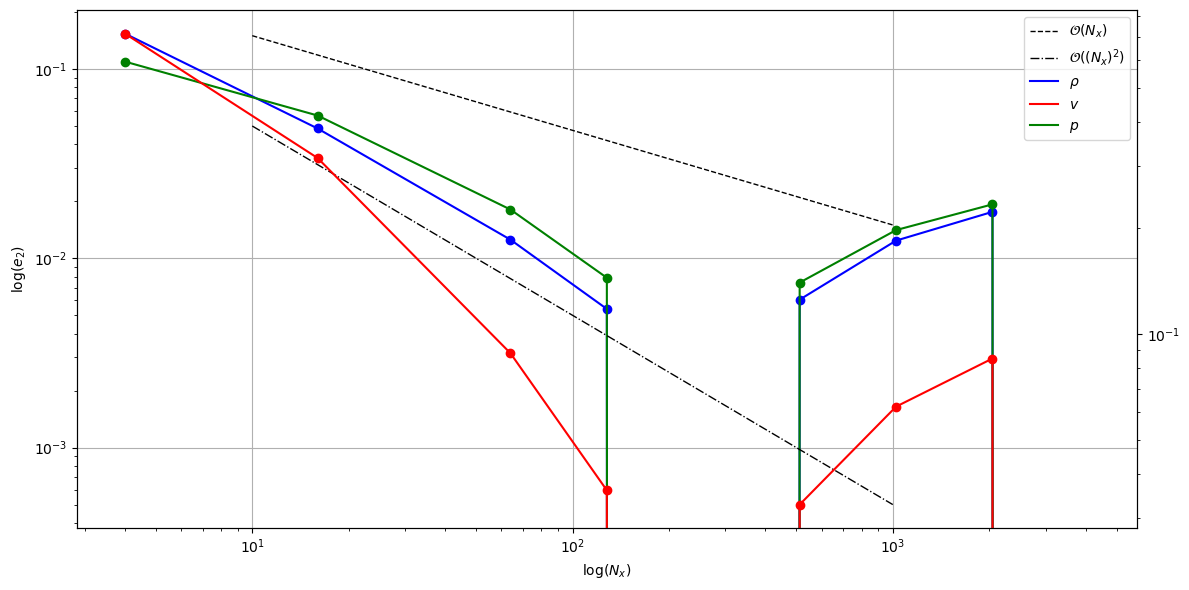

In [15]:
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11, 12]#!, 13, 14]
M = 8
file_gramian = [f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv" for base_tree_level in base_tree_level_vec]
data_gramian = [pd.read_csv(f) for f in file_gramian]

errors = {}
Nx = []
for key in ['rho', 'v', 'p']:
    errors[key] = []
    ref_solution = interp1d(data_gramian[-1]['x'], data_gramian[-1][key])  # Using the same data as reference for simplicity
    for tree_level in base_tree_level_vec:
        data_trixi = data_gramian[base_tree_level_vec.index(tree_level)]
        error = np.linalg.norm(ref_solution(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(ref_solution(data_trixi['x']), 2)
        errors[key].append(error)
        if key == 'rho':
            Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

fig, axs = plt.subplots(figsize=(12,6))
axs.plot(Nx, errors['rho'], marker='o', color='blue')
twinx = axs.twinx()
twinx.loglog(Nx, errors['v'], marker='o', color='red')
axs.loglog(Nx, errors['p'], marker='o', color='green')
axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
axs.plot([], [], 'b-', label='$\\rho$')
axs.plot([], [], 'r-', label='$v$')
axs.plot([], [], 'g-', label='$p$')
axs.set_xticks([10**1, 10**2, 10**3])
axs.set_xlabel('$\log(N_x)$')
axs.set_ylabel('$\log(e_2)$')
axs.grid(True)
axs.legend()

fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/GridConvergence_M8.pdf')
fig.show()

In [16]:
order_x = [10**(1), 10**(3)]
offset_first_order = 0.5
first_order_y = [(1 + offset_first_order) * 10**(-1), (1 + offset_first_order) * 10**(-4/2)] 
offset_second_order = -0.5
second_order_y = [(1 + offset_second_order) * 10**(-1), (1 + offset_second_order) * 10**(-3)] 

/tmp/ipykernel_32403/3906590078.py:37: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


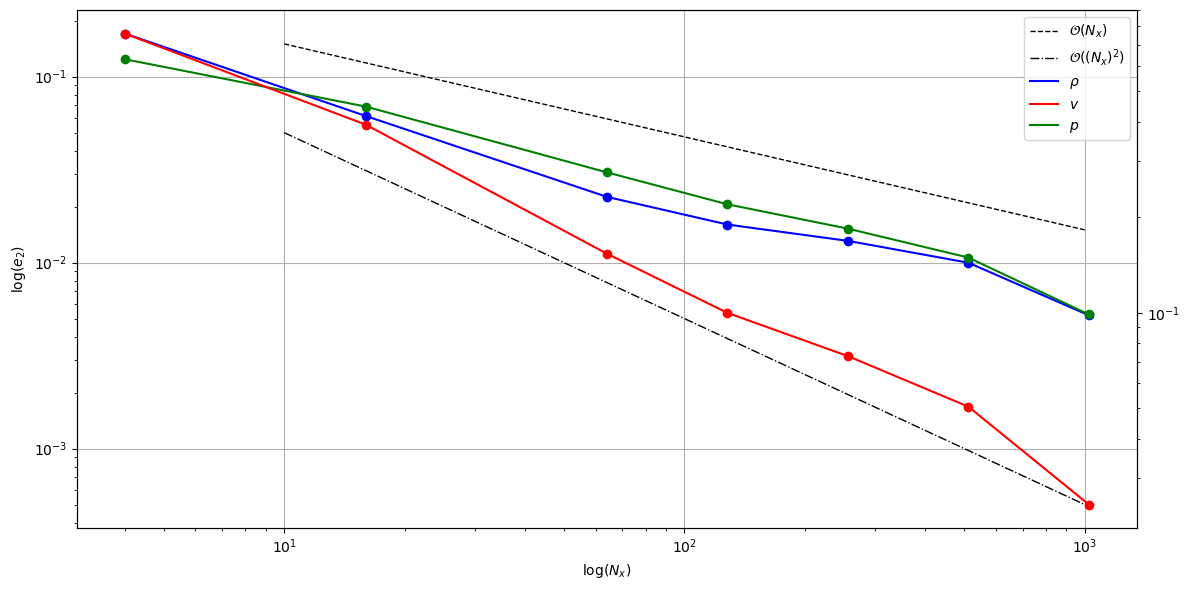

In [17]:
base_tree_level_vec = [2, 4, 6, 7, 8, 9, 10, 11]#!, 12, 13, 14]
M = 12
file_gramian = [f"../out/Riemann1D/Moments/gram_solution_M{M}_closure{closure}_Kn{Kn}_source{source}_T_end{T_end}_rho_L{rho_L}_rho_R{rho_R}_v_L{v_L}_v_R{v_R}_theta_L{theta_L}_theta_R{theta_R}_base_tree_level{base_tree_level}_polydeg{polydeg}_rho_v_p.csv" for base_tree_level in base_tree_level_vec]
data_gramian = [pd.read_csv(f) for f in file_gramian]


errors = {}
Nx = []
for key in ['rho', 'v', 'p']:
    errors[key] = []
    ref_solution = interp1d(data_gramian[-1]['x'], data_gramian[-1][key])  # Using the same data as reference for simplicity
    for tree_level in base_tree_level_vec[:-1]:
        data_trixi = data_gramian[base_tree_level_vec.index(tree_level)]
        error = np.linalg.norm(ref_solution(data_trixi['x']) - data_trixi[key], 2) / np.linalg.norm(ref_solution(data_trixi['x']), 2)
        errors[key].append(error)
        if key == 'rho':
            Nx.append(2**tree_level) # Assuming 3 cells per leaf node -> * 3 in the brackets

fig, axs = plt.subplots(figsize=(12,6))
axs.plot(Nx, errors['rho'], marker='o', color='blue')
twinx = axs.twinx()
twinx.loglog(Nx, errors['v'], marker='o', color='red')
axs.loglog(Nx, errors['p'], marker='o', color='green')
axs.loglog(order_x, first_order_y, 'k--', label='$\mathcal{O}(N_x)$', linewidth=1)
axs.loglog(order_x, second_order_y, 'k-.', label='$\mathcal{O}((N_x)^{2})$', linewidth=1)
axs.plot([], [], 'b-', label='$\\rho$')
axs.plot([], [], 'r-', label='$v$')
axs.plot([], [], 'g-', label='$p$')
axs.set_xticks([10**1, 10**2, 10**3])
axs.set_xlabel('$\log(N_x)$')
axs.set_ylabel('$\log(e_2)$')
axs.grid(True)
axs.legend()

fig.tight_layout()
fig.savefig('../out/Figures/Riemann1D/GridConvergence_M12.pdf')
fig.show()